In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [7]:
transform=transforms.Compose([
transforms.ToTensor(),
transforms.Normalize((0.5,),(0.5))  
])

In [8]:
train_set=torchvision.datasets.FashionMNIST(root='./data',train=True,download=True,
transform=transform)
test_set=torchvision.datasets.FashionMNIST(root='./data',train=False,download=True,
transform=transform)

In [9]:
im,lbl=train_set[0]
print(im.shape)
print(len(train_set))
print(len(test_set))

torch.Size([1, 28, 28])
60000
10000


In [10]:
trl=DataLoader(train_set,batch_size=32,shuffle=True)
tstl=DataLoader(test_set,batch_size=32,shuffle=False)

In [11]:
class CNNclassifier1(nn.Module):
    def __init__(self):
        super().__init__()
        self.c1=nn.Conv2d(in_channels=1,out_channels=32,kernel_size=3,padding=1)
        self.c2=nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,padding=1)
        self.c3=nn.Conv2d(in_channels=64,out_channels=128,kernel_size=3,padding=1)
        self.pool=nn.MaxPool2d(kernel_size=2,stride=2)
        self.l1=nn.Linear(128*3*3,64)
        self.l2=nn.Linear(64,32)
        self.l3=nn.Linear(32,10)
    def forward(self,x):
        x=self.pool(torch.relu(self.c1(x)))
        x=self.pool(torch.relu(self.c2(x)))
        x=self.pool(torch.relu(self.c3(x)))
        x=x.view(x.size(0),-1)
        x=torch.relu(self.l1(x))
        x=torch.relu(self.l2(x))
        x=self.l3(x)
        return x

In [14]:
from torchsummary import summary

model=CNNclassifier1()
criterion=nn.CrossEntropyLoss()
op=optim.Adam(model.parameters(),lr=0.001)
if torch.cuda.is_available():
    print(torch.cuda.is_available())
    device=torch.device('cuda')
    model.to(device)


summary(model,input_size=(1,28,28))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
         MaxPool2d-2           [-1, 32, 14, 14]               0
            Conv2d-3           [-1, 64, 14, 14]          18,496
         MaxPool2d-4             [-1, 64, 7, 7]               0
            Conv2d-5            [-1, 128, 7, 7]          73,856
         MaxPool2d-6            [-1, 128, 3, 3]               0
            Linear-7                   [-1, 64]          73,792
            Linear-8                   [-1, 32]           2,080
            Linear-9                   [-1, 10]             330
Total params: 168,874
Trainable params: 168,874
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.42
Params size (MB): 0.64
Estimated Total Size (MB): 1.06
-------------------------------------------

In [15]:
epochs=3
running_loss=0.0

for i in range(epochs):
    model.train()
    for a,b in trl:
        op.zero_grad()
        pred=model(a)
        loss=criterion(pred,b)
        loss.backward()
        op.step()
        running_loss+=loss.item()
    print(f"Loss:{i}",running_loss/len(trl))

Loss:0 0.4768900075316429
Loss:1 0.7710726777036985
Loss:2 1.0182545082290968


Accuracy Score: 90.11
Classification Report:               precision    recall  f1-score   support

 T-shirt/top       0.86      0.84      0.85      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.79      0.91      0.85      1000
       Dress       0.90      0.92      0.91      1000
        Coat       0.88      0.78      0.83      1000
      Sandal       0.99      0.96      0.98      1000
       Shirt       0.76      0.71      0.73      1000
     Sneaker       0.95      0.95      0.95      1000
         Bag       0.96      0.99      0.97      1000
  Ankle boot       0.95      0.97      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



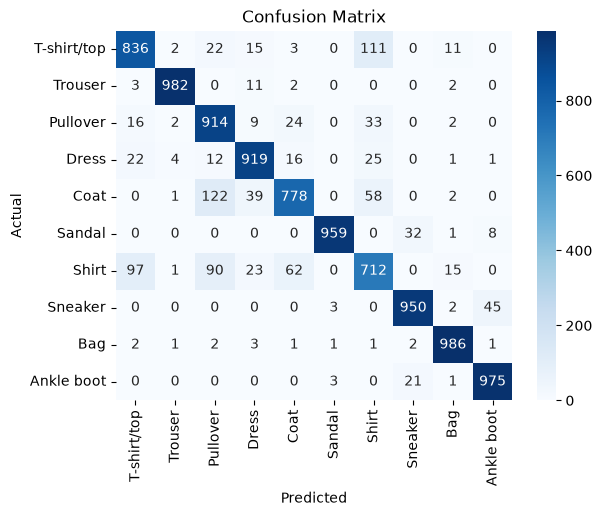

In [16]:
t=0
c=0
act=[]
pre=[]
model.eval()
with torch.no_grad():
    for img,labels in tstl:
        output=model(img)
        _,predicted=torch.max(output,1)
        t=t+labels.size(0)
        c+=(predicted==labels).sum().item()
        pre.extend(predicted.cpu().numpy())
        act.extend(labels.cpu().numpy())
accuracy=c/t*100
print("Accuracy Score:",accuracy)
conf_matrix=confusion_matrix(act,pre)
class_report=classification_report(act,pre,target_names=test_set.classes)
print("Classification Report:",class_report)
sns.heatmap(conf_matrix,annot=True,fmt='d',cmap='Blues',xticklabels=test_set.classes,yticklabels=test_set.classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

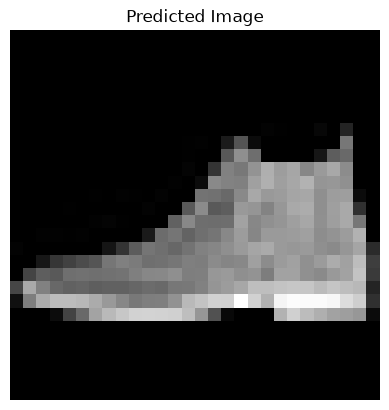

Actual:Ankle boot

Predicted:Ankle boot



In [17]:
with torch.no_grad():
    img1,label=test_set[0]
    output=model(img1.unsqueeze(0))
    _,pred=torch.max(output,1)
    classes=test_set.classes
    img1 = img1 * 0.5 + 0.5
    plt.imshow(img1.squeeze(),cmap="gray")
    plt.title("Predicted Image")
    plt.axis('off')
    plt.show()
    print(f"Actual:{classes[label]}\n")
    print(f"Predicted:{classes[pred.item()]}\n")


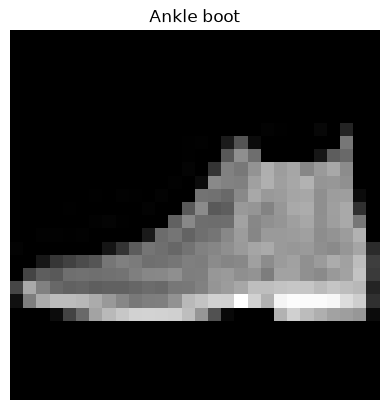

In [18]:
original_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=None
)

image, label = original_dataset[0]

plt.imshow(image, cmap='gray')
plt.title(original_dataset.classes[label])
plt.axis('off')
plt.show()